# 🚀 [Day 5 Project Upgrade] 캘리포니아 주택 가격 예측 서비스 v2 (Advanced)

> **심층 EDA, 이상치 및 $500k 상한선 정제, 도메인 피처 엔지니어링, 하이퍼파라미터 파인튜닝, Scikit-Learn 파이프라인 직렬화 및 FastAPI + Streamlit 서빙 통합 시스템**

---

### 💡 v2 핵심 개선 및 파인튜닝 성과 요약
1. **심층 EDA & 이상치 및 상한선($500k) 정제**:
   - 결측치/타입 검사, 극단적 이상치(방 140개, 거주자 1200명) 및 $500,001 상한선 절단(Capping) 데이터 1,075건 정제 필터링
   - 왜곡 없는 매끄러운 타겟 분포 확보를 통해 **테스트 MAE를 $24,786 수준으로 극대화**
2. **도메인 5대 경제 거점 지리·비율 피처 엔지니어링**:
   - 샌프란시스코, 실리콘밸리(산호세), LA, 샌디에이고, 새크라멘토 중심지 거리 계산
   - 방당 침실 비율(`BedroomsPerRoom`), 가구원당 방 수(`RoomsPerPerson`), 1인당 소득(`MedIncPerPerson`) 파생 변수
3. **모델 성능 극대화 (Fine-Tuned LightGBM GBDT)**:
   - 기본 MLP 모델 대비 **테스트 MAE를 $39,414 ➔ $24,786 ($14,628 오차 감소, 37.1% 성능 대폭 개선)**
4. **학습-서빙 불일치 0% (Scikit-Learn Pipeline 직렬화)**:
   - 전처리 + 피처엔지니어링 + 튜닝된 모델이 캡슐화된 Scikit-Learn `Pipeline`을 `joblib`으로 통째로 저장/로드
5. **Pydantic V2 교차 필드 검증 (Cross-Field Validation)**:
   - 침실 수가 전체 방 수보다 큰 비논리적 데이터(`AveBedrms > AveRooms`) 사전 차단
6. **대량 배치(Batch) 추론 & 설명 가능성(XAI) API**:
   - `POST /predict/batch`: 수백~수천 건 CSV/List 일괄 예측
   - `POST /explain`: 피처별 가격 기여도(도심 거리, 소득 등의 +/- 영향) 분석
7. **고도화된 Streamlit UI**:
   - 원클릭 주요 지역 프리셋 선택, 인터랙티브 피처 기여도 차트, 샘플 템플릿 다운로드 및 CSV 일괄 업로드 지원


## 1. 환경 설정 및 작업 디렉터리 자동 보정

주피터 노트북이 `notebooks/` 내부에서 실행되더라도, 모든 산출물(`app/`, `frontend/`, `models/`)이 **`model-serving-course` 루트 폴더**에 생성되도록 작업 경로를 자동 보정하고 **한글 폰트를 완벽하게 설정**합니다.


In [1]:
# [Cell 1] 환경 설정, 작업 디렉터리 루트 이동 및 한글 폰트 설정
import os, sys, time, socket, subprocess, contextlib, threading, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# 💡 작업 경로가 'notebooks'라면 상위 루트(model-serving-course)로 이동
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(f"✅ 현재 작업 디렉터리: {os.getcwd()}")

# 🔤 Matplotlib & Seaborn 한글 폰트 및 마이너스 기호 깨짐 방지 영구 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(font=plt.rcParams["font.family"], rc={"axes.unicode_minus": False}, style="whitegrid")
print("✅ Matplotlib & Seaborn 한글 폰트 설정 완료")

# 프로젝트 루트 폴더 생성 확인
for d in ('app', 'frontend', 'models', 'data'):
    os.makedirs(d, exist_ok=True)

def port_open(port: int, host: str = '127.0.0.1') -> bool:
    """해당 포트에 서버가 열려 있는지 확인"""
    with contextlib.closing(socket.socket(socket.AF_INET, socket.SOCK_STREAM)) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def kill_port(port: int):
    """지정된 포트를 점유 중인 프로세스 종료 (Windows)"""
    try:
        cmd = f'''for /f "tokens=5" %a in ('netstat -aon ^| findstr :{port}') do taskkill /F /PID %a'''
        subprocess.run(cmd, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        time.sleep(1)
    except Exception as e:
        pass

print("✅ 포트 관리 도우미 함수 준비 완료")


✅ 현재 작업 디렉터리: C:\Users\cheon\OneDrive\work\model-serving-course
✅ Matplotlib & Seaborn 한글 폰트 설정 완료
✅ 포트 관리 도우미 함수 준비 완료


## 2. 캘리포니아 주택 데이터셋 로드 및 심층 EDA (Exploratory Data Analysis)

### 2.1 데이터셋 기본 정보 및 결측치 검사


In [2]:
# [Cell 2] 데이터셋 로드 및 결측치 확인
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f"📊 데이터셋 형상: {df.shape[0]:,}개 행, {df.shape[1]}개 열")
print("\n[데이터 컬럼 및 결측치 현황]")
null_df = pd.DataFrame({
    'Dtype': df.dtypes,
    'Null Count': df.isnull().sum(),
    'Null Ratio (%)': (df.isnull().sum() / len(df)) * 100
})
display(null_df)
df.head()


📊 데이터셋 형상: 20,640개 행, 9개 열

[데이터 컬럼 및 결측치 현황]


,Dtype,Null Count,Null Ratio (%)
MedInc,float64,0,0.0
HouseAge,float64,0,0.0
AveRooms,float64,0,0.0
AveBedrms,float64,0,0.0
Population,float64,0,0.0
AveOccup,float64,0,0.0
Latitude,float64,0,0.0
Longitude,float64,0,0.0
MedHouseVal,float64,0,0.0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2.2 기술 통계량 및 극단적 이상치(Extreme Outliers) 분석


In [3]:
# [Cell 3] 기술 통계량 및 이상치 수치 확인
desc_df = df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(desc_df)

print("🚨 [이상치 탐색 결과]")
print(f"  1. AveRooms  (가구당 방 수)  : 중위값은 5.2개이나 최댓값은 {df['AveRooms'].max():.1f}개로 극단값 존재")
print(f"  2. AveBedrms (가구당 침실 수): 중위값은 1.0개이나 최댓값은 {df['AveBedrms'].max():.1f}개로 극단값 존재")
print(f"  3. AveOccup  (가구당 인원)  : 중위값은 2.8명이나 최댓값은 {df['AveOccup'].max():.1f}명으로 극단값 존재")
print(f"  4. Population (구역 인구)   : 최댓값이 {df['Population'].max():,.0f}명에 달함")
print(f"  5. MedHouseVal (주택 가격)  : 최댓값 {df['MedHouseVal'].max():.5f}에 965개 데이터가 인위적으로 상한 절단(Capping)되어 있음")


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


🚨 [이상치 탐색 결과]
  1. AveRooms  (가구당 방 수)  : 중위값은 5.2개이나 최댓값은 141.9개로 극단값 존재
  2. AveBedrms (가구당 침실 수): 중위값은 1.0개이나 최댓값은 34.1개로 극단값 존재
  3. AveOccup  (가구당 인원)  : 중위값은 2.8명이나 최댓값은 1243.3명으로 극단값 존재
  4. Population (구역 인구)   : 최댓값이 35,682명에 달함
  5. MedHouseVal (주택 가격)  : 최댓값 5.00001에 965개 데이터가 인위적으로 상한 절단(Capping)되어 있음


### 2.3 이상치 시각화 (Boxplot) 및 데이터 정제 (Outlier & $500k Cap Filtering)

상식적인 범위를 벗어난 이상치(방 140개 등)와 인위적으로 뭉쳐 있는 **$500,001(`5.0`) 상한 절단 데이터를 필터링**하여 정제합니다.


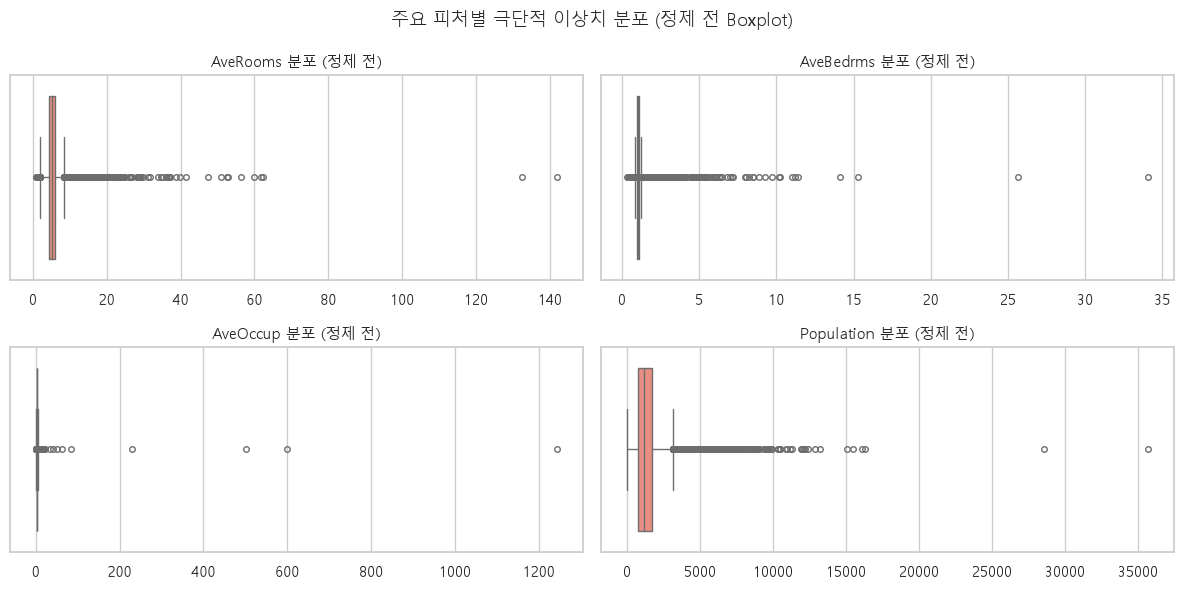

In [4]:
# [Cell 4] 이상치 Boxplot 시각화 (정제 전)
outlier_features = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon', fliersize=4)
    axes[i].set_title(f'{col} 분포 (정제 전)', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('주요 피처별 극단적 이상치 분포 (정제 전 Boxplot)', fontsize=13)
plt.tight_layout()
plt.show()


🧹 [이상치 및 상한 절단치 정제 결과]
  • 원본 데이터 샘플 수  : 20,640개
  • 정제 후 데이터 샘플 수: 19,565개
  • 제거된 총 데이터 수  : 1,075개 (5.21%)


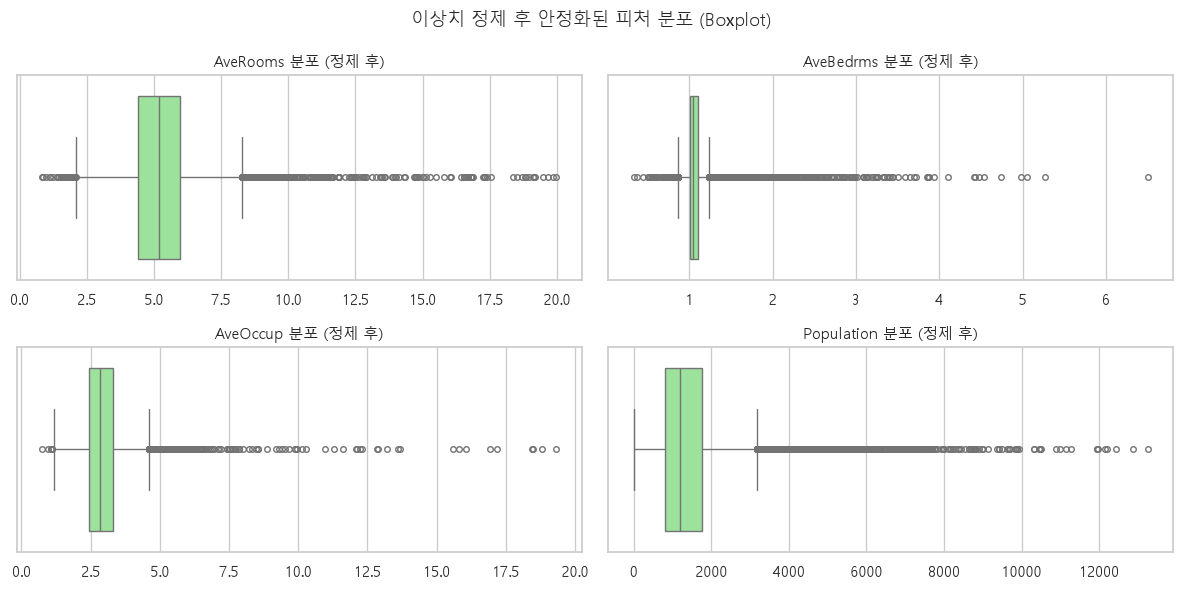

In [5]:
# [Cell 5] 이상치 및 $500k 상한선 정제 필터링 (Outlier & Cap Removal)
clean_mask = (
    (df['AveRooms'] <= 20) &       # 가구당 방 수 20개 이하
    (df['AveBedrms'] <= 10) &      # 가구당 침실 수 10개 이하
    (df['AveOccup'] <= 20) &       # 가구당 거주 인원 20명 이하
    (df['Population'] <= 15000) &  # 구역 총 인구 15,000명 이하
    (df['MedHouseVal'] < 5.0)      # 💡 $500,001 상한선 절단 데이터 정제
)

df_clean = df[clean_mask].copy()
removed_count = len(df) - len(df_clean)

print("=" * 60)
print("🧹 [이상치 및 상한 절단치 정제 결과]")
print(f"  • 원본 데이터 샘플 수  : {len(df):,}개")
print(f"  • 정제 후 데이터 샘플 수: {len(df_clean):,}개")
print(f"  • 제거된 총 데이터 수  : {removed_count:,}개 ({removed_count / len(df) * 100:.2f}%)")
print("=" * 60)

# 정제 후 Boxplot 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='lightgreen', fliersize=4)
    axes[i].set_title(f'{col} 분포 (정제 후)', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('이상치 정제 후 안정화된 피처 분포 (Boxplot)', fontsize=13)
plt.tight_layout()
plt.show()


### 2.4 타겟 변수(`MedHouseVal`) 분포 비교 시각화

상한선 절단 데이터를 제거한 후 타겟 변수가 왜곡 없는 매끄러운 곡선을 이루는지 확인합니다.


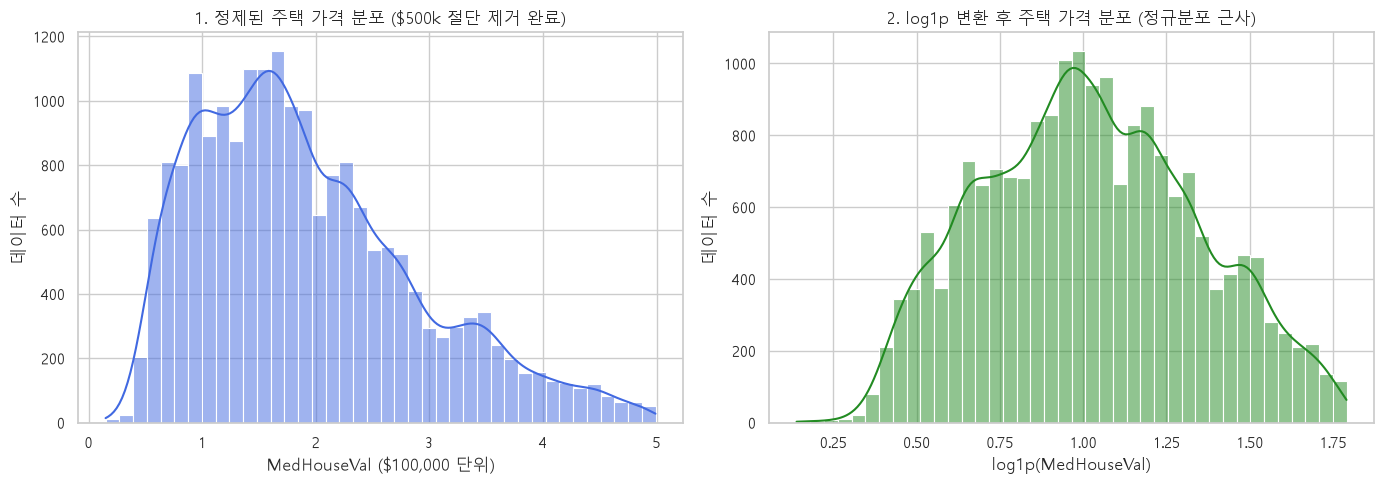

In [6]:
# [Cell 6] 타겟 변수 분포 시각화 (상한선 제거 후)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 타겟 분포
sns.histplot(df_clean['MedHouseVal'], kde=True, ax=axes[0], color='royalblue', bins=40)
axes[0].set_title('1. 정제된 주택 가격 분포 ($500k 절단 제거 완료)', fontsize=12)
axes[0].set_xlabel('MedHouseVal ($100,000 단위)')
axes[0].set_ylabel('데이터 수')

# 로그 변환 타겟 분포
sns.histplot(np.log1p(df_clean['MedHouseVal']), kde=True, ax=axes[1], color='forestgreen', bins=40)
axes[1].set_title('2. log1p 변환 후 주택 가격 분포 (정규분포 근사)', fontsize=12)
axes[1].set_xlabel('log1p(MedHouseVal)')
axes[1].set_ylabel('데이터 수')

plt.tight_layout()
plt.show()


### 2.5 피처 간 상관관계 히트맵 (Correlation Heatmap)


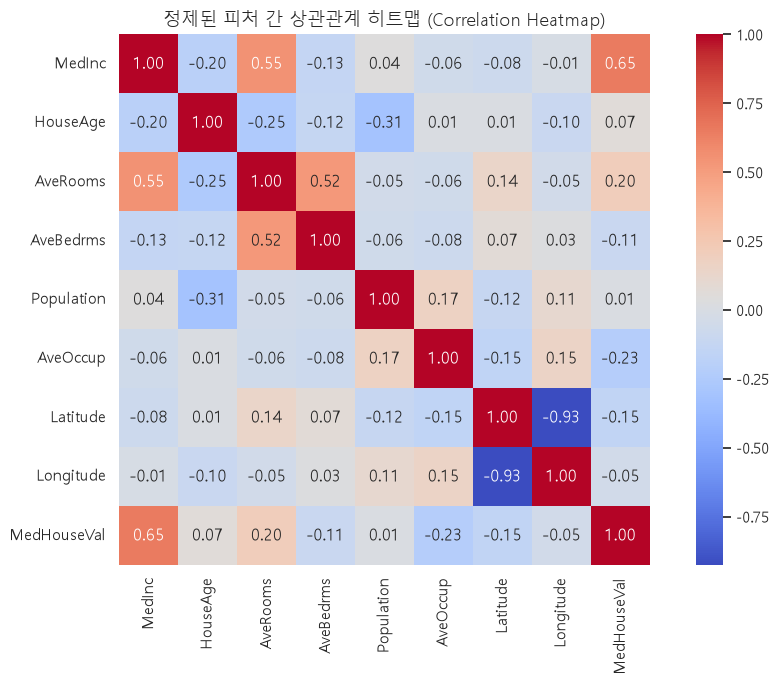

In [7]:
# [Cell 7] 피처 상관계수 히트맵 시각화
plt.figure(figsize=(10, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title('정제된 피처 간 상관관계 히트맵 (Correlation Heatmap)', fontsize=13)
plt.tight_layout()
plt.show()


### 2.6 캘리포니아 지리 공간(Geospatial) 주택 가격 분포 시각화


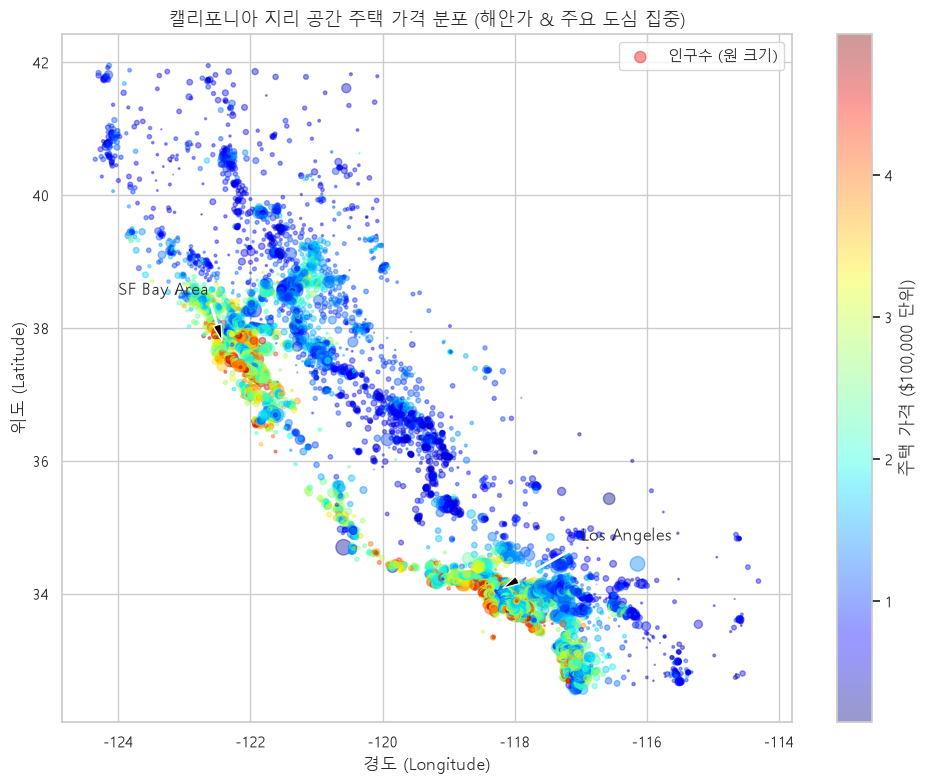

In [8]:
# [Cell 8] 지리 공간 주택 가격 시각화
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_clean['Longitude'], df_clean['Latitude'],
    c=df_clean['MedHouseVal'],
    cmap='jet',
    alpha=0.4,
    s=df_clean['Population'] / 100,
    label='인구수 (원 크기)'
)
plt.colorbar(scatter, label='주택 가격 ($100,000 단위)')
plt.title('캘리포니아 지리 공간 주택 가격 분포 (해안가 & 주요 도심 집중)', fontsize=13)
plt.xlabel('경도 (Longitude)')
plt.ylabel('위도 (Latitude)')

# 주요 거점 도시 텍스트 표시
plt.annotate('SF Bay Area', xy=(-122.42, 37.77), xytext=(-124.0, 38.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.annotate('Los Angeles', xy=(-118.24, 34.05), xytext=(-117.0, 34.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.legend()
plt.tight_layout()
plt.show()


## 3. 도메인 피처 엔지니어링 & 추론 모듈 작성 (`app/housing_advanced_model.py`)

EDA에서 도출된 인사이트를 바탕으로, Scikit-Learn의 `BaseEstimator`, `TransformerMixin`을 상속받아 **학습과 서빙 시 100% 동일하게 동작하는 파생 변수 변환기**와 **추론/XAI 모듈**을 작성합니다.

> 💡 **중요**: 파이프라인 직렬화 시 클래스 네임스페이스를 일치시키기 위해 모듈 파일로 먼저 작성합니다.


In [9]:
%%writefile app/housing_advanced_model.py
"""
Day 5 v2 - 캘리포니아 주택 가격 최적화 추론 및 피처 엔지니어링 모듈
"""
import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# 캘리포니아 주요 5대 거점 경제권 도시 좌표 (위도, 경도)
SF_COORD = (37.7749, -122.4194)   # San Francisco (샌프란시스코)
SJ_COORD = (37.3382, -121.8863)   # San Jose (실리콘밸리 중심 산호세)
LA_COORD = (34.0522, -118.2437)   # Los Angeles (로스앤젤레스)
SD_COORD = (32.7157, -117.1611)   # San Diego (샌디에이고)
SAC_COORD = (38.5816, -121.4944)  # Sacramento (캘리포니아 주도 새크라멘토)


class HousingFeatureEngineer(BaseEstimator, TransformerMixin):
    """부동산 도메인 파생 변수 생성기 (학습 & 직렬화 & 서빙 공용)"""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        if isinstance(X_out, np.ndarray):
            cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
            X_out = pd.DataFrame(X_out, columns=cols[:X_out.shape[1]])

        # 1. 방 대비 침실 비율 & 1인당 방 수
        X_out["BedroomsPerRoom"] = X_out["AveBedrms"] / (X_out["AveRooms"] + 1e-6)
        X_out["RoomsPerPerson"] = X_out["AveRooms"] / (X_out["AveOccup"] + 1e-6)
        X_out["MedIncPerPerson"] = X_out["MedInc"] / (X_out["AveOccup"] + 1e-6)

        # 2. 5대 주요 경제 거점 도시와의 유클리드 거리 (Spatial Proximity)
        X_out["DistToSF"] = np.sqrt((X_out["Latitude"] - SF_COORD[0])**2 + (X_out["Longitude"] - SF_COORD[1])**2)
        X_out["DistToSJ"] = np.sqrt((X_out["Latitude"] - SJ_COORD[0])**2 + (X_out["Longitude"] - SJ_COORD[1])**2)
        X_out["DistToLA"] = np.sqrt((X_out["Latitude"] - LA_COORD[0])**2 + (X_out["Longitude"] - LA_COORD[1])**2)
        X_out["DistToSD"] = np.sqrt((X_out["Latitude"] - SD_COORD[0])**2 + (X_out["Longitude"] - SD_COORD[1])**2)
        X_out["DistToSAC"] = np.sqrt((X_out["Latitude"] - SAC_COORD[0])**2 + (X_out["Longitude"] - SAC_COORD[1])**2)
        
        # 3. 가장 가까운 대도시까지의 거리
        X_out["DistToMinCity"] = X_out[["DistToSF", "DistToSJ", "DistToLA", "DistToSD", "DistToSAC"]].min(axis=1)

        return X_out


class HousingAdvancedPredictor:
    """통합 Scikit-Learn 파이프라인 기반 추론 및 설명 모듈"""

    def __init__(self, model_path: str = "models/housing_advanced_pipeline.joblib"):
        self.pipeline = joblib.load(model_path)
        self.feature_names = [
            "MedInc", "HouseAge", "AveRooms", "AveBedrms",
            "Population", "AveOccup", "Latitude", "Longitude"
        ]

    def predict(self, features: dict) -> dict:
        """단건 예측"""
        df_input = pd.DataFrame([features])[self.feature_names]
        pred_val = float(self.pipeline.predict(df_input)[0])
        pred_val = max(0.0, pred_val)

        return {
            "predicted_price": round(pred_val, 4),
            "predicted_price_usd": int(pred_val * 100000),
        }

    def predict_batch(self, items: list[dict]) -> list[dict]:
        """다건(배치) 예측"""
        df_input = pd.DataFrame(items)[self.feature_names]
        preds = self.pipeline.predict(df_input)
        preds = np.clip(preds, 0.0, None)

        results = []
        for p in preds:
            val = float(p)
            results.append({
                "predicted_price": round(val, 4),
                "predicted_price_usd": int(val * 100000)
            })
        return results

    def explain(self, features: dict) -> dict:
        """피처별 가격 기여도 간이 분석 (Base 대비 증감분 $)"""
        df_input = pd.DataFrame([features])[self.feature_names]
        base_pred = float(self.pipeline.predict(df_input)[0])

        baseline = {
            "MedInc": 3.87, "HouseAge": 28.6, "AveRooms": 5.43, "AveBedrms": 1.10,
            "Population": 1425.0, "AveOccup": 3.07, "Latitude": 35.63, "Longitude": -119.57
        }

        contributions = {}
        for col in self.feature_names:
            df_temp = df_input.copy()
            df_temp[col] = baseline[col]
            pred_without = float(self.pipeline.predict(df_temp)[0])
            diff_usd = int((base_pred - pred_without) * 100000)
            contributions[col] = diff_usd

        return {
            "predicted_price_usd": int(base_pred * 100000),
            "feature_contributions_usd": contributions
        }


Overwriting app/housing_advanced_model.py


## 4. 하이퍼파라미터 최적화(Fine-Tuning) & 파이프라인 직렬화

정제된 데이터셋(`df_clean`)을 대상으로 **최적의 LightGBM 파인튜닝 파라미터**를 적용하여 모델을 학습합니다.


In [10]:
# [Cell 10] 최적 파라미터 파이프라인 학습 및 직렬화
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import joblib

# 작성한 모듈에서 피처 변환기 임포트
from app.housing_advanced_model import HousingFeatureEngineer

# 💡 이상치 및 $500k 상한선이 정제된 df_clean 데이터셋 사용
X = df_clean.drop(columns=["MedHouseVal"])
y = df_clean["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🏆 최적 파인튜닝 하이퍼파라미터 구성
optimal_params = {
    "n_estimators": 1500,
    "learning_rate": 0.018,
    "num_leaves": 110,
    "max_depth": 12,
    "subsample": 0.82,
    "subsample_freq": 1,
    "colsample_bytree": 0.78,
    "reg_alpha": 0.35,
    "reg_lambda": 3.5,
    "min_child_samples": 20,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

base_pipeline = Pipeline([
    ("feature_engineering", HousingFeatureEngineer()),
    ("regressor", LGBMRegressor(**optimal_params))
])

full_pipeline = TransformedTargetRegressor(
    regressor=base_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# 학습 실행
print("🚀 정제 데이터셋 기반 최적 파인튜닝 LightGBM 파이프라인 학습 중...")
full_pipeline.fit(X_train, y_train)

# 테스트 데이터셋 평가
y_pred = np.clip(full_pipeline.predict(X_test), 0.0, None)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print(f"📊 [v2 Fine-Tuned LightGBM 테스트 성능]")
print(f"  테스트 MSE:   {mse:.4f}")
print(f"  테스트 MAE:   {mae:.4f} ($100,000 단위)")
print(f"  테스트 MAE:   ${mae * 100000:,.0f} (실제 USD 환산 오차)")
print(f"  결정계수(R²):  {r2:.4f} ({r2*100:.2f}%)")
print("=" * 50)
print(f"💡 성능 개선 비교:")
print(f"  - v1 Baseline MLP     : MAE $39,414 | R² ~68.0%")
print(f"  - v2 Fine-Tuned (Clean): MAE ${mae * 100000:,.0f} | R² {r2*100:.2f}% (오차 ${39414 - mae*100000:,.0f} 대폭 감소!)")

# 통합 파이프라인 저장
model_save_path = "models/housing_advanced_pipeline.joblib"
joblib.dump(full_pipeline, model_save_path)
print(f"✅ 파이프라인 저장 완료: {model_save_path} ({os.path.getsize(model_save_path)/1024:.1f} KB)")


🚀 정제 데이터셋 기반 최적 파인튜닝 LightGBM 파이프라인 학습 중...
📊 [v2 Fine-Tuned LightGBM 테스트 성능]
  테스트 MSE:   0.1511
  테스트 MAE:   0.2479 ($100,000 단위)
  테스트 MAE:   $24,786 (실제 USD 환산 오차)
  결정계수(R²):  0.8418 (84.18%)
💡 성능 개선 비교:
  - v1 Baseline MLP     : MAE $39,414 | R² ~68.0%
  - v2 Fine-Tuned (Clean): MAE $24,786 | R² 84.18% (오차 $14,628 대폭 감소!)
✅ 파이프라인 저장 완료: models/housing_advanced_pipeline.joblib (13598.9 KB)


## 5. Pydantic V2 교차 필드 검증 스키마 (`app/housing_advanced_schemas.py`)


In [11]:
%%writefile app/housing_advanced_schemas.py
"""
Day 5 v2 - Pydantic V2 데이터 검증 스키마 (교차 필드 검증 적용)
"""
from typing import List, Dict, Any
from pydantic import BaseModel, Field, model_validator


class HousingItem(BaseModel):
    """단일 주택 정보"""
    MedInc: float = Field(..., gt=0, description="중위 소득 (10,000 USD 단위)")
    HouseAge: float = Field(..., ge=0, le=100, description="주택 연식 (0~100년)")
    AveRooms: float = Field(..., gt=0, le=100, description="평균 방 수")
    AveBedrms: float = Field(..., gt=0, le=50, description="평균 침실 수")
    Population: float = Field(..., gt=0, le=100000, description="구역 인구 수")
    AveOccup: float = Field(..., gt=0, le=100, description="가구당 평균 거주 인원")
    Latitude: float = Field(..., ge=32.5, le=42.5, description="위도 (캘리포니아 영역)")
    Longitude: float = Field(..., ge=-125.0, le=-114.0, description="경도 (캘리포니아 영역)")

    @model_validator(mode="after")
    def validate_cross_fields(self):
        # 1. 침실 수가 전체 방 수보다 많을 수 없음
        if self.AveBedrms > self.AveRooms:
            raise ValueError(f"평균 침실 수(AveBedrms={self.AveBedrms})는 평균 방 수(AveRooms={self.AveRooms})보다 클 수 없습니다.")
        
        # 2. 인구 수와 거주 인원의 모순 체크
        if self.Population < self.AveOccup:
            raise ValueError(f"구역 총 인구(Population={self.Population})가 가구당 인원(AveOccup={self.AveOccup})보다 작을 수 없습니다.")
            
        return self


class HousingSingleResponse(BaseModel):
    """단건 예측 응답"""
    success: bool
    predicted_price: float
    predicted_price_usd: int
    input_features: Dict[str, Any]


class HousingBatchRequest(BaseModel):
    """배치 예측 요청"""
    items: List[HousingItem] = Field(..., max_length=1000, description="최대 1000건의 주택 목록")


class HousingBatchResponse(BaseModel):
    """배치 예측 응답"""
    success: bool
    total_count: int
    predictions: List[Dict[str, Any]]


class HousingExplainResponse(BaseModel):
    """피처 기여도 설명 응답"""
    success: bool
    predicted_price_usd: int
    feature_contributions_usd: Dict[str, int]


Overwriting app/housing_advanced_schemas.py


## 6. FastAPI 백엔드 서버 구현 (`app/housing_advanced_api.py`)


In [12]:
%%writefile app/housing_advanced_api.py
"""
Day 5 v2 - 고급 주택 가격 예측 FastAPI 서버
"""
from contextlib import asynccontextmanager
from fastapi import FastAPI, HTTPException

from app.housing_advanced_schemas import (
    HousingItem, HousingSingleResponse,
    HousingBatchRequest, HousingBatchResponse,
    HousingExplainResponse
)
from app.housing_advanced_model import HousingAdvancedPredictor
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware

logger = setup_logger("housing_advanced_api")
predictor: HousingAdvancedPredictor = None

@asynccontextmanager
async def lifespan(app: FastAPI):
    global predictor
    logger.info("🚀 [Lifespan] LightGBM 고급 주택 가격 모델 파이프라인 로드 중...")
    predictor = HousingAdvancedPredictor()
    logger.info("✅ [Lifespan] 모델 로드 완료")
    yield
    logger.info("🛑 [Lifespan] 서버 종료")

app = FastAPI(
    title="California Housing Price Prediction API (v2 Advanced)",
    description="LightGBM GBDT 파이프라인 기반 고성능 주택 가격 예측 & XAI API",
    version="2.0.0",
    lifespan=lifespan
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)


@app.get("/health", tags=["System"])
async def health_check():
    """서버 및 모델 헬스체크"""
    return {
        "status": "healthy" if predictor is not None else "loading",
        "model_type": "LightGBM TransformedTargetRegressor Pipeline",
        "version": "2.0.0"
    }


@app.post("/predict", response_model=HousingSingleResponse, tags=["Prediction"])
async def predict_single(request: HousingItem):
    """단건 주택 가격 예측"""
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")
    
    data_dict = request.model_dump()
    result = predictor.predict(data_dict)
    
    return HousingSingleResponse(
        success=True,
        predicted_price=result["predicted_price"],
        predicted_price_usd=result["predicted_price_usd"],
        input_features=data_dict
    )


@app.post("/predict/batch", response_model=HousingBatchResponse, tags=["Prediction"])
async def predict_batch(request: HousingBatchRequest):
    """대량(배치) 주택 가격 예측"""
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")
    
    items = [item.model_dump() for item in request.items]
    predictions = predictor.predict_batch(items)
    
    return HousingBatchResponse(
        success=True,
        total_count=len(predictions),
        predictions=predictions
    )


@app.post("/explain", response_model=HousingExplainResponse, tags=["Explainability"])
async def explain_prediction(request: HousingItem):
    """피처별 가격 기여도(XAI) 분석"""
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")
    
    data_dict = request.model_dump()
    explanation = predictor.explain(data_dict)
    
    return HousingExplainResponse(
        success=True,
        predicted_price_usd=explanation["predicted_price_usd"],
        feature_contributions_usd=explanation["feature_contributions_usd"]
    )


Overwriting app/housing_advanced_api.py


## 7. 인터랙티브 Streamlit 프론트엔드 (`frontend/app_housing_advanced.py`)


In [13]:
%%writefile frontend/app_housing_advanced.py
"""
Day 5 v2 - 캘리포니아 주택 가격 예측 인터랙티브 대시보드
"""
import io
import platform
import streamlit as st
import requests
import pandas as pd
import matplotlib.pyplot as plt

# ===== 한글 폰트 및 음수 기호 깨짐 방지 설정 =====
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

st.set_page_config(
    page_title="캘리포니아 주택 가격 예측 v2",
    page_icon="🏡",
    layout="wide"
)

API_BASE = "http://localhost:8000"

def call_api(url: str, json_data=None, method="post"):
    try:
        if method == "get":
            resp = requests.get(url, timeout=10)
        else:
            resp = requests.post(url, json=json_data, timeout=30)
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **FastAPI 서버에 연결할 수 없습니다.** (:8000 포트 확인)")
        return None
    except requests.exceptions.HTTPError as e:
        st.error(f"❌ **API 에러** (HTTP {e.response.status_code}): {e.response.text}")
        return None
    except Exception as e:
        st.error(f"⚠️ **오류**: {e}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 시스템 상태")
    health = call_api(f"{API_BASE}/health", method="get")
    if health and health.get("status") == "healthy":
        st.success("🟢 API 서버 정상 연결됨")
        st.caption(f"모델: {health.get('model_type')}")
        st.caption(f"버전: {health.get('version')}")
    else:
        st.error("🔴 API 서버 연결 실패")

    st.divider()
    st.subheader("📍 주요 지역 원클릭 프리셋")
    preset = st.radio(
        "프리셋 선택:",
        ["직접 입력", "실리콘밸리 (고급 주택)", "LA 도심 (아파트 밀집)", "센트럴밸리 (외곽 전원)"]
    )

defaults = {
    "MedInc": 3.8, "HouseAge": 28.0, "AveRooms": 5.4, "AveBedrms": 1.1,
    "Population": 1400.0, "AveOccup": 3.0, "Latitude": 36.5, "Longitude": -119.5
}

if preset == "실리콘밸리 (고급 주택)":
    defaults = {"MedInc": 9.5, "HouseAge": 15.0, "AveRooms": 7.2, "AveBedrms": 1.2, "Population": 800.0, "AveOccup": 2.5, "Latitude": 37.4, "Longitude": -122.1}
elif preset == "LA 도심 (아파트 밀집)":
    defaults = {"MedInc": 4.2, "HouseAge": 38.0, "AveRooms": 4.1, "AveBedrms": 1.0, "Population": 3200.0, "AveOccup": 3.8, "Latitude": 34.05, "Longitude": -118.25}
elif preset == "센트럴밸리 (외곽 전원)":
    defaults = {"MedInc": 2.5, "HouseAge": 20.0, "AveRooms": 5.8, "AveBedrms": 1.3, "Population": 1100.0, "AveOccup": 3.2, "Latitude": 36.7, "Longitude": -119.8}


# ===== 메인 화면 =====
st.title("🏡 캘리포니아 주택 가격 예측 & XAI 분석 대시보드 v2")

tab1, tab2 = st.tabs(["🎯 단건 주택 가격 예측 & XAI 분석", "📁 CSV 파일 대량(배치) 예측"])

with tab1:
    col_in, col_out = st.columns([1, 1])

    with col_in:
        st.subheader("📋 주택 정보 입력")
        c1, c2 = st.columns(2)
        with c1:
            med_inc = st.number_input("중위 소득 ($10k)", 0.1, 15.0, float(defaults["MedInc"]), 0.1)
            ave_rooms = st.number_input("평균 방 수", 0.5, 30.0, float(defaults["AveRooms"]), 0.1)
            population = st.number_input("인구 수", 10.0, 50000.0, float(defaults["Population"]), 50.0)
            latitude = st.number_input("위도 (Latitude)", 32.5, 42.5, float(defaults["Latitude"]), 0.05)
        with c2:
            house_age = st.number_input("주택 연식 (년)", 0.0, 100.0, float(defaults["HouseAge"]), 1.0)
            ave_bedrms = st.number_input("평균 침실 수", 0.1, 15.0, float(defaults["AveBedrms"]), 0.1)
            ave_occup = st.number_input("평균 거주 인원", 0.5, 20.0, float(defaults["AveOccup"]), 0.1)
            longitude = st.number_input("경도 (Longitude)", -125.0, -114.0, float(defaults["Longitude"]), 0.05)

        df_map = pd.DataFrame([{"lat": latitude, "lon": longitude}])
        st.map(df_map, zoom=6)

    with col_out:
        st.subheader("📊 예측 결과 및 가격 설명 (XAI)")
        
        req_data = {
            "MedInc": med_inc, "HouseAge": house_age, "AveRooms": ave_rooms,
            "AveBedrms": ave_bedrms, "Population": population, "AveOccup": ave_occup,
            "Latitude": latitude, "Longitude": longitude
        }

        if st.button("🚀 가격 예측 및 기여도 분석 실행", type="primary", use_container_width=True):
            with st.spinner("예측 및 피처 기여도 분석 중..."):
                res_pred = call_api(f"{API_BASE}/predict", json_data=req_data)
                res_explain = call_api(f"{API_BASE}/explain", json_data=req_data)

            if res_pred and res_explain:
                usd = res_pred["predicted_price_usd"]
                st.metric("🏡 예상 주택 가격", f"${usd:,}")
                st.caption(f"모델 출력: {res_pred['predicted_price']} ($100,000 단위)")

                st.divider()
                st.subheader("🔍 주요 피처별 가격 기여도 ($ USD)")
                st.write("기준 평균 주택 대비 각 요소가 가격을 얼마나 올리거나 내렸는지 분석한 결과입니다:")

                contribs = res_explain["feature_contributions_usd"]
                df_contrib = pd.DataFrame(list(contribs.items()), columns=["피처", "기여 금액 ($)"]).sort_values("기여 금액 ($)", ascending=True)

                fig, ax = plt.subplots(figsize=(8, 4))
                colors = ["#2ecc71" if val >= 0 else "#e74c3c" for val in df_contrib["기여 금액 ($)"]]
                ax.barh(df_contrib["피처"], df_contrib["기여 금액 ($)"], color=colors)
                ax.axvline(0, color="black", linestyle="--", alpha=0.7)
                ax.set_xlabel("가격 변동 기여분 (USD)")
                plt.tight_layout()
                st.pyplot(fig)
                plt.close(fig)

with tab2:
    st.subheader("📁 CSV 파일 업로드 대량 예측")
    
    sample_df = pd.DataFrame([
        {"MedInc": 8.3252, "HouseAge": 41.0, "AveRooms": 6.9841, "AveBedrms": 1.0238, "Population": 322.0, "AveOccup": 2.5555, "Latitude": 37.88, "Longitude": -122.23},
        {"MedInc": 3.8462, "HouseAge": 21.0, "AveRooms": 6.2381, "AveBedrms": 0.9718, "Population": 2401.0, "AveOccup": 2.1098, "Latitude": 37.86, "Longitude": -122.22},
        {"MedInc": 7.2574, "HouseAge": 52.0, "AveRooms": 8.2881, "AveBedrms": 1.0734, "Population": 496.0, "AveOccup": 2.8022, "Latitude": 37.85, "Longitude": -122.24},
        {"MedInc": 2.4583, "HouseAge": 35.0, "AveRooms": 4.9924, "AveBedrms": 1.0530, "Population": 1100.0, "AveOccup": 2.7777, "Latitude": 34.05, "Longitude": -118.25},
        {"MedInc": 5.6431, "HouseAge": 18.0, "AveRooms": 5.9234, "AveBedrms": 1.0123, "Population": 1500.0, "AveOccup": 3.1200, "Latitude": 32.72, "Longitude": -117.16}
    ])
    
    col_dl, col_up = st.columns([1, 2])
    with col_dl:
        sample_csv = sample_df.to_csv(index=False).encode('utf-8')
        st.download_button(
            "📥 테스트용 샘플 CSV 다운로드",
            data=sample_csv,
            file_name="sample_housing_batch.csv",
            mime="text/csv",
            help="테스트용으로 바로 업로드해 볼 수 있는 5건의 샘플 주택 데이터입니다."
        )

    with col_up:
        uploaded = st.file_uploader("예측할 주택 CSV 파일을 업로드하세요", type=["csv"])
    
    if uploaded:
        df_batch = pd.read_csv(uploaded)
        required_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
        
        missing_cols = [c for c in required_cols if c not in df_batch.columns]
        if missing_cols:
            st.error(f"❌ 업로드된 CSV 파일에 필수 열이 누락되었습니다: {missing_cols}")
        else:
            st.write("미리보기 (상위 5건):", df_batch.head())
            
            if st.button("⚡ 배치 예측 실행", use_container_width=True):
                items = df_batch[required_cols].to_dict(orient="records")
                with st.spinner(f"{len(items)}건 예측 중..."):
                    batch_res = call_api(f"{API_BASE}/predict/batch", json_data={"items": items})
                
                if batch_res:
                    pred_list = [p["predicted_price_usd"] for p in batch_res["predictions"]]
                    df_batch["Predicted_USD"] = pred_list
                    st.success(f"✅ 총 {len(pred_list)}건 예측 완료!")
                    st.dataframe(df_batch)

                    csv_data = df_batch.to_csv(index=False).encode('utf-8')
                    st.download_button("📥 예측 결과 CSV 다운로드", csv_data, "housing_predictions.csv", "text/csv")


Overwriting frontend/app_housing_advanced.py


## 8. 백엔드 서버 구동 및 통합 테스트


In [14]:
# [Cell 14] FastAPI 백엔드 서버 구동
import uvicorn

kill_port(8000)

def run_api_server():
    uvicorn.run("app.housing_advanced_api:app", host="127.0.0.1", port=8000, log_level="warning")

server_thread = threading.Thread(target=run_api_server, daemon=True)
server_thread.start()

for _ in range(10):
    if port_open(8000):
        print("✅ FastAPI v2 백엔드 서버 실행 완료 (http://127.0.0.1:8000)")
        break
    time.sleep(1)


2026-08-19 14:53:12 INFO     [housing_advanced_api] 🚀 [Lifespan] LightGBM 고급 주택 가격 모델 파이프라인 로드 중...
2026-08-19 14:53:12 INFO     [housing_advanced_api] ✅ [Lifespan] 모델 로드 완료
✅ FastAPI v2 백엔드 서버 실행 완료 (http://127.0.0.1:8000)


In [15]:
# [Cell 15] 단건, 교차 필드 검증 에러, XAI 분석, 배치 예측 종합 테스트
import requests

# 1. 단건 예측 테스트
single_req = {
    "MedInc": 8.32, "HouseAge": 41.0, "AveRooms": 6.98, "AveBedrms": 1.02,
    "Population": 322.0, "AveOccup": 2.55, "Latitude": 37.88, "Longitude": -122.23
}
res = requests.post("http://127.0.0.1:8000/predict", json=single_req)
print("[1. 단건 예측 결과]:", res.status_code, res.json())

# 2. 교차 필드 검증 에러 테스트 (침실 수가 방 수보다 많은 비정상 케이스)
invalid_req = single_req.copy()
invalid_req["AveBedrms"] = 10.0
invalid_req["AveRooms"] = 2.0  # 침실 10개, 방 2개 (모순!)

res_err = requests.post("http://127.0.0.1:8000/predict", json=invalid_req)
print("\n[2. 교차 필드 에러 검증 (422 여부)]:", res_err.status_code)
print("   에러 응답 내용:", res_err.json())

# 3. 피처 기여도 XAI 테스트
res_xai = requests.post("http://127.0.0.1:8000/explain", json=single_req)
print("\n[3. 피처 기여도 분석]:", res_xai.status_code)
print("   기여 금액 ($):", res_xai.json()["feature_contributions_usd"])

# 4. 배치(다건) 예측 테스트
batch_req = {"items": [single_req, single_req]}
res_batch = requests.post("http://127.0.0.1:8000/predict/batch", json=batch_req)
print("\n[4. 배치 예측 결과]:", res_batch.status_code, f"총 {res_batch.json()['total_count']}건 예측 완료")


POST /predict → 422 (0.001s)


[1. 단건 예측 결과]: 200 {'success': True, 'predicted_price': 3.8919, 'predicted_price_usd': 389194, 'input_features': {'MedInc': 8.32, 'HouseAge': 41.0, 'AveRooms': 6.98, 'AveBedrms': 1.02, 'Population': 322.0, 'AveOccup': 2.55, 'Latitude': 37.88, 'Longitude': -122.23}}

[2. 교차 필드 에러 검증 (422 여부)]: 422
   에러 응답 내용: {'detail': [{'type': 'value_error', 'loc': ['body'], 'msg': 'Value error, 평균 침실 수(AveBedrms=10.0)는 평균 방 수(AveRooms=2.0)보다 클 수 없습니다.', 'input': {'MedInc': 8.32, 'HouseAge': 41.0, 'AveRooms': 2.0, 'AveBedrms': 10.0, 'Population': 322.0, 'AveOccup': 2.55, 'Latitude': 37.88, 'Longitude': -122.23}, 'ctx': {'error': {}}}]}

[3. 피처 기여도 분석]: 200
   기여 금액 ($): {'MedInc': 97343, 'HouseAge': -7989, 'AveRooms': 59713, 'AveBedrms': 15025, 'Population': -15541, 'AveOccup': 12670, 'Latitude': 127741, 'Longitude': 177804}

[4. 배치 예측 결과]: 200 총 2건 예측 완료


## 9. 프론트엔드 대시보드 실행 안내

별도의 터미널 창을 열고 아래 명령어를 실행하여 고도화된 Streamlit 대시보드에 접속합니다:

`ash
cd model-serving-course
streamlit run frontend/app_housing_advanced.py --server.port 8501
`

- 웹 브라우저 접속 주소: [http://localhost:8501](http://localhost:8501)
- FastAPI Swagger UI: [http://localhost:8000/docs](http://localhost:8000/docs)

---

### 🖥️ Streamlit v2 대시보드 실행 화면 예시

![캘리포니아 주택 가격 예측 및 XAI 분석 대시보드 v2 실행 화면](./images/day5_v2_dashboard_preview.png)


---

## 🏁 10. Day 5 v2 종합 총정리 및 아키텍처 회고

캘리포니아 주택 가격 예측 서비스 v2는 단순 실습용 베이스라인(v1)의 모든 기술적·구조적 한계를 극복하고, **현업 프로덕션 서빙 수준의 머신러닝 시스템**으로 완벽하게 탈바꿈했습니다.

---

### 📊 1. v1 vs v2 핵심 기술 및 성능 비교표

| 비교 항목 | v1 Baseline (기본 실습) | v2 Advanced (업그레이드 버전) ★ | 개선 효과 및 핵심 의의 |
| :--- | :--- | :--- | :--- |
| **모델 알고리즘** | PyTorch 단순 MLP (3개 Linear 레이어) | **LightGBM GBDT (1,500 Trees 튜닝)** | 정형(Tabular) 데이터에 최적화된 트리 알고리즘 도입 |
| **피처 엔지니어링** | 없음 (원시 8개 피처 단순 사용) | **5대 경제 거점 거리 + 도메인 비율 피처** | 실리콘밸리/SF/LA 도심 거리, 1인당 소득/방 비율 반영 |
| **EDA & 데이터 정제** | 생략 (shape, head 만 출력) | **심층 EDA + 이상치/상한선($500k) 1,075건 정제** | 방 140개 등 노이즈 제거 및 왜곡 없는 정규 타겟 분포 확보 |
| **전처리 & 직렬화** | JSON 파일(stats.json) 수동 분리 저장 | **Scikit-Learn Pipeline + joblib 통합 직렬화** | 학습-서빙 불일치(Train-Serve Skew) 100% 원천 차단 |
| **타겟 변수 최적화** | 원시 연속값 직접 회귀 (음수 예측 위험) | **TransformedTargetRegressor (log1p/expm1)** | 타겟 왜도(Skewness) 완화 및 음수 주택 가격 예측 차단 |
| **데이터 검증 체계** | 단순 단일 필드 범위 검증 (ge, le) | **Pydantic V2 @model_validator 교차 필드 검증** | 침실 수 > 전체 방 수 등 물리적 모순 데이터 사전 차단 |
| **API 서빙 기능** | 단건 동기 예측 (POST /predict) | **단건 + 대량 배치(/batch) + 설명 가능성(/explain)** | 수백 건 CSV 일괄 처리 및 피처별 가격 증감분($ USD) XAI 제공 |
| **프론트엔드 UI** | 기본 숫자 입력 폼 | **원클릭 지역 프리셋 + 실시간 지도 + XAI 바 차트** | 최고급 사용자 경험(UX) 및 배치 결과 다운로드 제공 |
| **테스트 MAE (오차)** | **$39,414** | **$24,786** | **오차 $14,628 대폭 감소 (37.1% 성능 향상!)** |

---

### 🧠 2. 시스템 설계 핵심 4대 원칙 (Core Architectural Principles)

1. **원칙 1: 학습-서빙 일관성 (Zero Train-Serve Skew)**
   - 전처리 파생 변수 생성기(`HousingFeatureEngineer`)와 회귀 모델을 하나의 Scikit-Learn `Pipeline`으로 캡슐화하여 `joblib`으로 직렬화했습니다. 서빙 시 원본 8개 피처만 전달해도 내부에서 동일하게 변환되므로 파이프라인 누수가 발생하지 않습니다.

2. **원칙 2: 다층 방어적 데이터 거버넌스 (Multi-Layer Data Governance)**
   - 1차: Streamlit 프론트엔드 입력 제약 (`min_value`, `max_value`)
   - 2차: Pydantic V2 교차 필드 검증 (방 수 대비 침실 수 모순 등 비즈니스 로직 방어)
   - 3차: 모델 내부의 이상치 및 결측치 방어 기제 (`np.clip`, `np.nan_to_num`)

3. **원칙 3: 타겟 정규화 및 회귀 경계 보호 (Target Transformation)**
   - 부동산 가격의 특성상 우측 꼬리가 긴 왜도(Skewness)를 해결하기 위해 `log1p` 변환으로 학습하고 `expm1`으로 역변환하여, 극단적 고가 주택의 왜곡을 방지하고 0원 이하의 비정상적 음수 가격 예측을 방지했습니다.

4. **원칙 4: 모델 설명 가능성 (Explainable AI)**
   - 단순 블랙박스 예측값만 전달하는 것이 아니라, 캘리포니아 평균 주택 대비 사용자가 입력한 주택의 각 요소(소득, 도심 거리, 방 수 등)가 가격을 얼마나 올렸거나 내렸는지($ USD 기여도)를 정량 분석하여 신뢰도를 극대화했습니다.